In [123]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib.patches as mpatches
import math
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import emcee


In [107]:
backend_file = '/Users/eb35267/Desktop/code/chains/fiducial_plus_mass/samples.h5'

In [108]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24', r'Donnan+24 ultra high-$z$', 'Kokorev+25', 'Weibel+25']
include = [True, True, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood=include)

In [109]:
params = eMCMC.build_param_data({'dsigdz': {'fit': True}, 'dlogMcdz':{'fit':True}, 'dsigdlogM':{'fit':True}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [110]:
samples, best_fit, bounds, param_labels = my_UVLF.get_fit(backend_file = backend_file)

# Corner plot

In [116]:
importlib.reload(eplots)

/Users/eb35267/Desktop/code/home/escripts/eplots.py:663: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'$z \simeq {z}$')


<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [125]:
reader = emcee.backends.HDFBackend(backend_file)
sample_not_flat = reader.get_chain(discard = my_UVLF.burn_in, flat=False)

In [141]:
cut_sample = np.delete(sample_not_flat, 5, axis = 1) # Delete the walker that got stuck

In [ ]:
cut_sample_flat = cut_sample.reshape(-1, 8) # Flatten

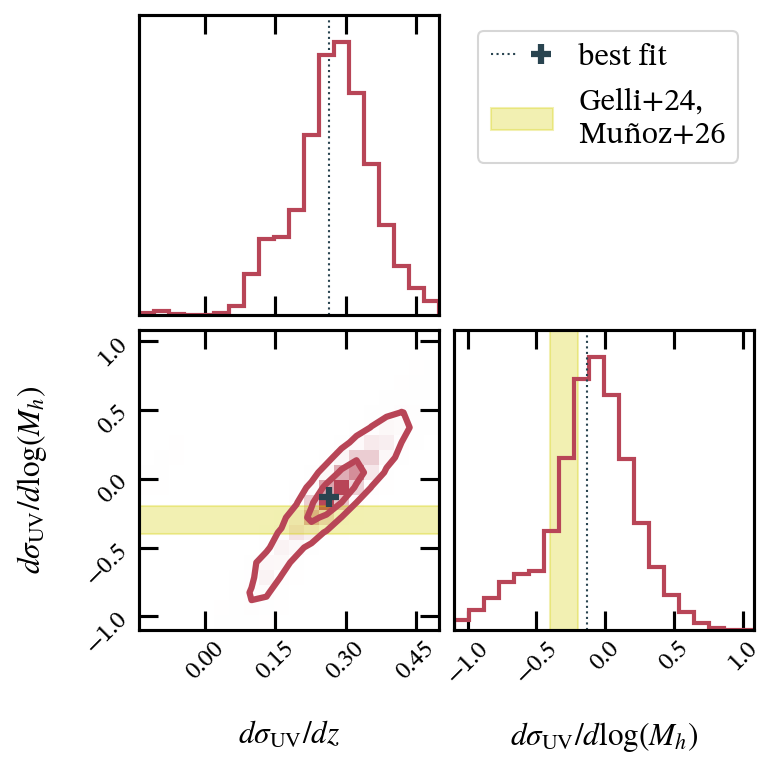

In [143]:
corner = eplots.make_corner(my_UVLF = my_UVLF, samples = cut_sample_flat, include_params = ['dsigdz', 'dsigdlogM'])

# for ax, zorder in zip([corner.axes[0], corner.axes[2]], [2, 1]):
#     ax.set_xlim(0.01, None)

# corner.axes[3].set_xlim(-1.3, 0.95)
# corner.axes[2].set_ylim(-1.3, 0.95)

corner.axes[0].axvline(best_fit[-2], color = eplots.navy, zorder = 1, lw = 1, ls = 'dotted')
corner.axes[2].fill_between([-1, 1], -0.4, -0.2, color = eplots.yellow, alpha = 0.3, zorder = 1)
corner.axes[3].fill_between([-0.4, -0.2], 0, 1e6, color = eplots.yellow, alpha = 0.3, zorder = 0)
corner.axes[3].axvline(best_fit[-1], color = eplots.navy, lw = 1, ls = 'dotted')

corner.axes[2].scatter(best_fit[-2], best_fit[-1], color = eplots.navy, s = 100, marker = '+', zorder = 2)

line = Line2D([0], [0], color=eplots.navy, lw = 1, ls = 'dotted')
scat = Line2D([0], [0], color=eplots.navy, marker='+', markersize=10, linestyle='None', markeredgewidth=3)
fill = mpatches.Patch(color=eplots.yellow, alpha=0.3)

corner.axes[1].legend([(line, scat), fill], ['best fit', 'Gelli+24,\nMuñoz+26'],
                      handler_map={(line, scat): HandlerTuple(ndivide=None)})

# corner.axes[1].scatter(0, -10, color = eplots.navy, s = 100, marker = '+', label = 'best fit')
# corner.axes[1].fill_between([0,0], 0, 0, color = eplots.turquoise, alpha = 0.2, label = 'other work')
# corner.axes[1].plot(0,0, color = eplots.navy, label = 'best fit')
# corner.axes[1].legend()

In [144]:
corner.savefig('/Users/eb35267/Desktop/figures/paper/corner.png', dpi = 300)

# UVLF

In [116]:
fiducial = [0.531, -0.001, 11.712, -0.057, -1.338, -0.113, 0.486, 0.229,
-0.152, 0.678]
redshift_dependent = [0.49, -0.019, 11.757, -0.04, -1.344, -0.117, 0.527,
0.236, 0, 0.668]
mass_dependent = [0.818, -0.032, 11.995, 0.05, -1.373, -0.138, 0.992,
0, -0.796, 0.677]
non_evolving = [0.388, -0.075, 12.051, 0.083, -1.388, -0.127, 0.754, 0, 
0, 0.3]

In [117]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
        fit_colors [list]: list of colors for the different models
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
    

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0, hspace = 0.3)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    

    ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+3)


    # Flatten all xdat and xerr across all redshifts and datasets
    MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o', 's', 's', 'D', 'P']
    if fit_colors is None:
        fit_colors = [eplots.turquoise, eplots.yellow, eplots.orange, eplots.green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err, MUVcenters, MUVwidths,sample)), alpha=6/max(nsamples, 6), 
                           color = eplots.red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)

            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, best_fit)), color = eplots.red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$', lw = 5)
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = f'{nsamples} samples from chain', linestyle = '-', lw = 5) # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, label, color, ls, lw in zip(comparison_fits, chi2_comparison, comparison_labels, fit_colors, 
                                        ['solid', 'dashed', 'dotted', 'dotted'], [7, 4, 2.5, 2.5]):
            if show_chi2:
                fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
            else:
                fit_label = f'{label}'
            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit)), color = color, 
                       label = fit_label, linestyle = ls, zorder = 1, lw = lw)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x, np.log10(y)-0.8, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 125)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels                                                                            
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels
        ax.set_title(fr'${round(z-z_err, 1)} \lesssim z \lesssim {round(z+z_err, 1)}$', fontsize = 20, pad = 8)


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    eplots.multicol(gs, axs, xlabel, ylabel, xlims = (np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25), ylims = (ylo, yhi), include_legend = True)
    
    return fig

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_12244/1230263309.py:123: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_12244/1230263309.py:123: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)


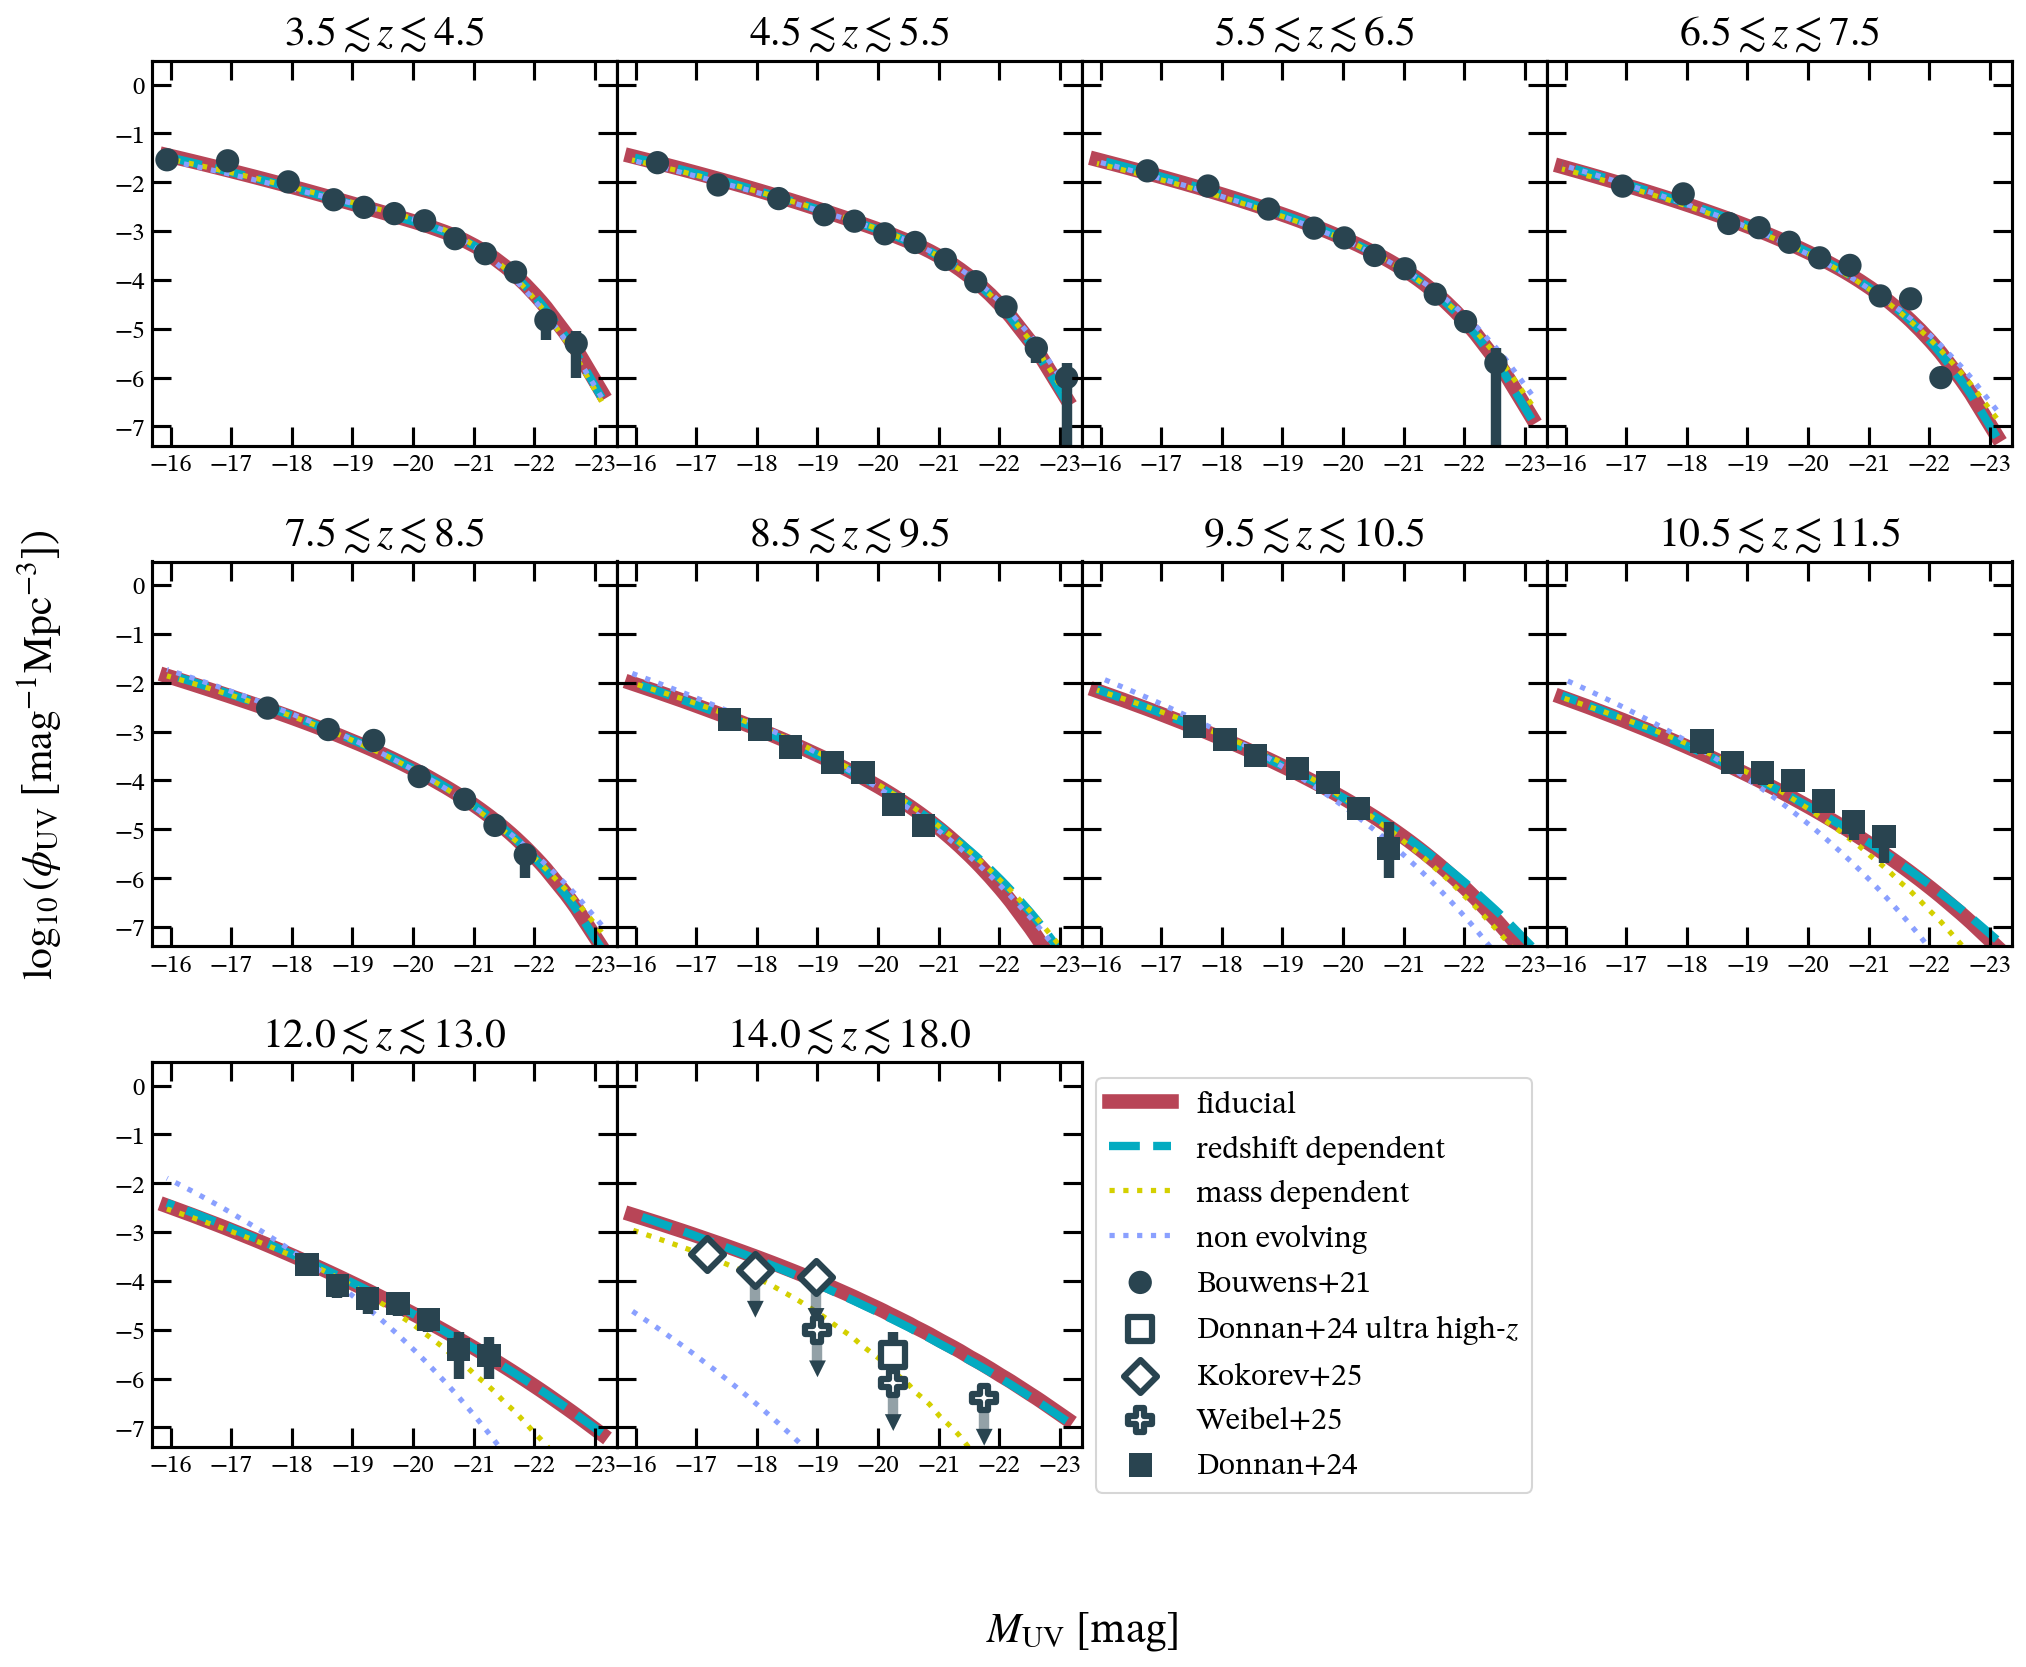

In [118]:
zs = [4, 5, 6, 7, 8, 9, 10, 11, 12.5, 16]
z_errs = [0.5, 0.5, 0.5, 0.5,0.5, 0.5, 0.5, 0.5, 0.5, 2]
evolving_UVLF = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [fiducial, redshift_dependent, mass_dependent, non_evolving],
                    comparison_labels = ['fiducial', 'redshift dependent', 'mass dependent', 'non evolving'], 
                    ncols = 4, 
                fit_colors = [eplots.red, eplots.turquoise, eplots.yellow, eplots.periwinkle], 
                z_plot = zs, z_errs = z_errs, show_chi2 = False)

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


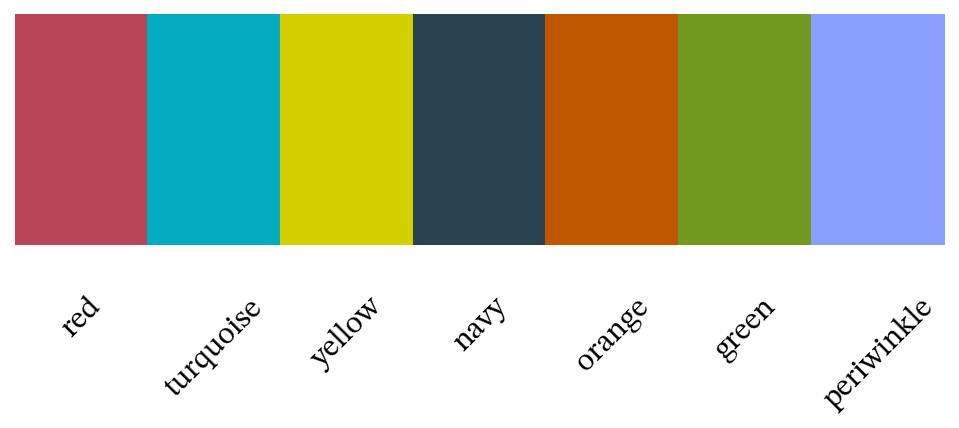

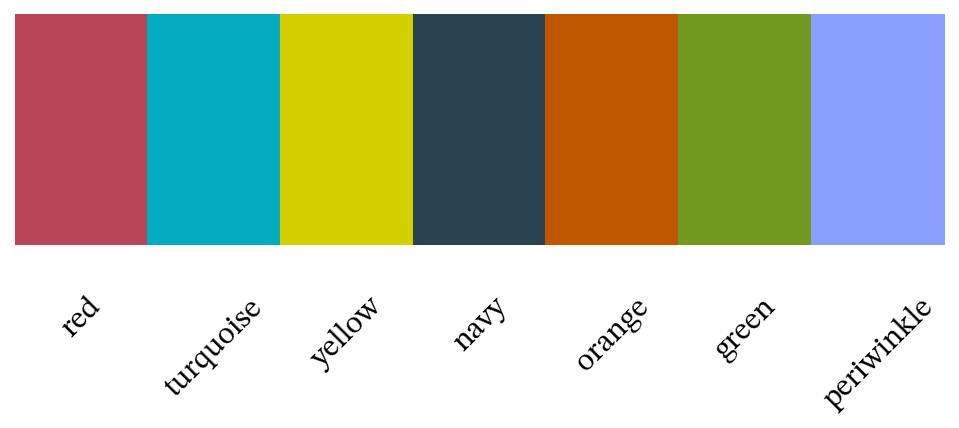

In [38]:
eplots.plot_colors()

# sigma(z)

In [79]:
samples[0]

array([ 0.52763228, -0.77725759, 12.28977972,  0.07518869, -0.70756565,
        0.26914656,  0.27592055])

In [83]:
def sigma(z, params, zpivot = 8):
    sig0 = params[:, -2].reshape(-1, 1)
    dsigdz = params[:,-1].reshape(-1, 1)
    min_sig = 0.3

    return np.clip(sig0 + dsigdz*(z-zpivot), a_min = min_sig, a_max = None)

In [84]:
Mhtab = np.arange(9, 13.5, 1.5)
zs = np.linspace(4, 13, 50)

cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)

In [85]:
distributions = np.percentile(sigma(zs, samples), q = [34, 50, 68], axis = 0)

In [46]:
def gelli(Mh):
    return (-0.34*np.log10(Mh)) + 4.5

## Attempting to quantify the mass dependence of sigma by tracing peak height over time

In [22]:
def get_Mh_ph(peak_height, my_UVLF):
    zs = my_UVLF.zs

    HMF = my_UVLF.HMFintclass
    target_sig = my_UVLF.CosmoParams.delta_crit_ST/peak_height

    sig_tab = HMF.sigmaMhtab

    target_Mhs = np.zeros_like(zs)
    for i, z in enumerate(zs):
        idx = np.argmin(np.abs(sig_tab[:,np.argmin(np.abs(HMF.zHMFtab - z))] - target_sig))
        target_Mhs[i] = HMF.Mhtab[idx]

    return target_Mhs

In [98]:
trace_const_overdensity = get_Mh_ph(3, my_UVLF)

In [99]:
gelli_const_overdensity = gelli(trace_const_overdensity)

In [100]:
gelli_const_overdensity

array([0.4 , 0.58, 0.76, 0.94, 1.12, 1.24, 1.42, 1.54, 1.78])

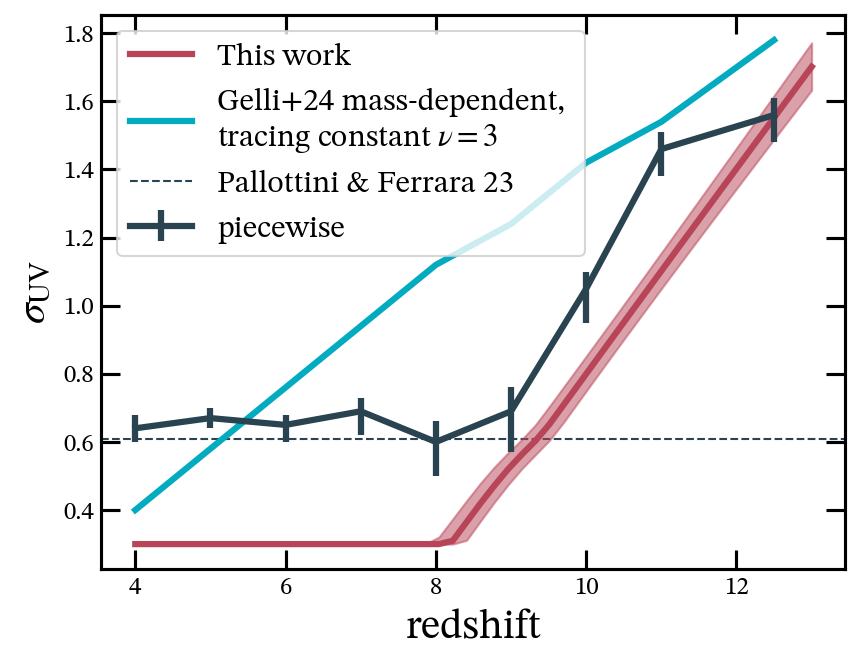

In [101]:
fig, ax = plt.subplots()

ax.plot(zs, distributions[1], color = eplots.red, ls = '-', label = 'This work')
ax.fill_between(zs, distributions[0], distributions[2], color = eplots.red, alpha = 0.5)


ax.plot(my_UVLF.zs, gelli_const_overdensity, color = eplots.turquoise, label = r'Gelli+24 mass-dependent, ' + '\n' + r'tracing constant $\nu = 3$')

lowers = np.array([0.04, 0.03, 0.05, 0.07, 0.1, 0.12, 0.1, 0.08, 0.08])
uppers = np.array([0.04, 0.03, 0.03, 0.04, 0.06, 0.07, 0.05, 0.05, 0.05])

yerr = np.vstack((lowers, uppers))

piecewise = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, [0.64, 0.67, 0.65, 0.69, 0.6, 0.69, 1.05, 1.46, 1.56], 0, 0, 0.3]
ax.errorbar(my_UVLF.zs, piecewise[-4], color = eplots.navy, yerr = yerr, ecolor = eplots.navy, 
            label = 'piecewise', markeredgecolor = eplots.navy, markersize = 7, fmt = '-')
ax.axhline(0.61, color = eplots.navy, ls = 'dashed', lw = 1, zorder = 0, label = 'Pallottini & Ferrara 23')

ax.set_xlabel('redshift')
ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

ax.legend()

In [112]:
fig.savefig('/Users/eb35267/Desktop/figures/paper/sigma(z).png', dpi = 300)